In [ ]:
from src import *
from myutils import *

import gc

In [ ]:
class v_sim(Simulator):
    def loc(self, n):
        fs = self.sampling_rate
        t = n / fs
        return 400 * t - 5 * DMD.PIXEL_SIZE

In [9]:
# Fisher Info Mat

fi11 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**2)
fi12 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**1)
fi22 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**0)
crb = np.linalg.inv(np.array([[fi11, fi12], [fi12, fi22]]))[0, 0]

In [ ]:
class VelocityEstimation:
    @classmethod
    def FromRaw(cls, raw: np.ndarray, metadata: MetaData):
        if metadata.measurement.upper() == 'SPADE':
            expt = SPADE(raw, velocity=True)
        elif metadata.measurement.upper() == 'DI':
            expt = DI(raw, velocity=True)
        else:
            raise ValueError
        
        del raw

        # gc.collect()
        expt.est_all(metadata)
        return expt.estimates


    # @classmethod
    # def FromEstimates(cls, Estimates_instance: Estimates):
    #     c: Estimates = np.copy(Estimates_instance).item()
    #     del Estimates_instance

    #     if c.metadata.measurement.upper() == 'SPADE':
    #         expt = SPADE(cropped=c.cropped_data, noise=c.noise)
    #     elif c.metadata.measurement.upper() == 'DI':
    #         expt = DI(amplitude=c.metadata.amplitude, cropped=c.cropped_data, noise=c.noise)
    #     else:
    #         raise ValueError

    #     gc.collect()
    #     expt.est_all(c.metadata)
    #     return expt.estimates

In [ ]:
# for v in np.linspace(200, 400, 51):
#     m = 'spade'

#     meta = MetaData(m.upper(), int(v), timestamp=np.load(rf'/Volumes/nvmeOFwiz/20241121/{m}_v/{m}_v{v}_d0_timestamp.npy'))
#     raw = np.load(rf'/Volumes/nvmeOFwiz/20241121/{m}_v/{m}_v{v}_d0_raw.npy')

#     c = VelocityEstimation.FromRaw(raw, meta)

#     c.savez('__v_est__')

In [13]:
dix, diy, spadex, spadey = [], [], [], []

for f in glob('__v_est__/di*'):
    c = LoadEstimates(f)
    dix.append(c.metadata.ground_truth)
    diy.append(c.velocity_estimates.var() * c.photons.mean())


for f in glob('__v_est__/spade*'):
    c = LoadEstimates(f)
    spadex.append(c.metadata.ground_truth)
    spadey.append(c.velocity_estimates.var() * c.photons.mean())

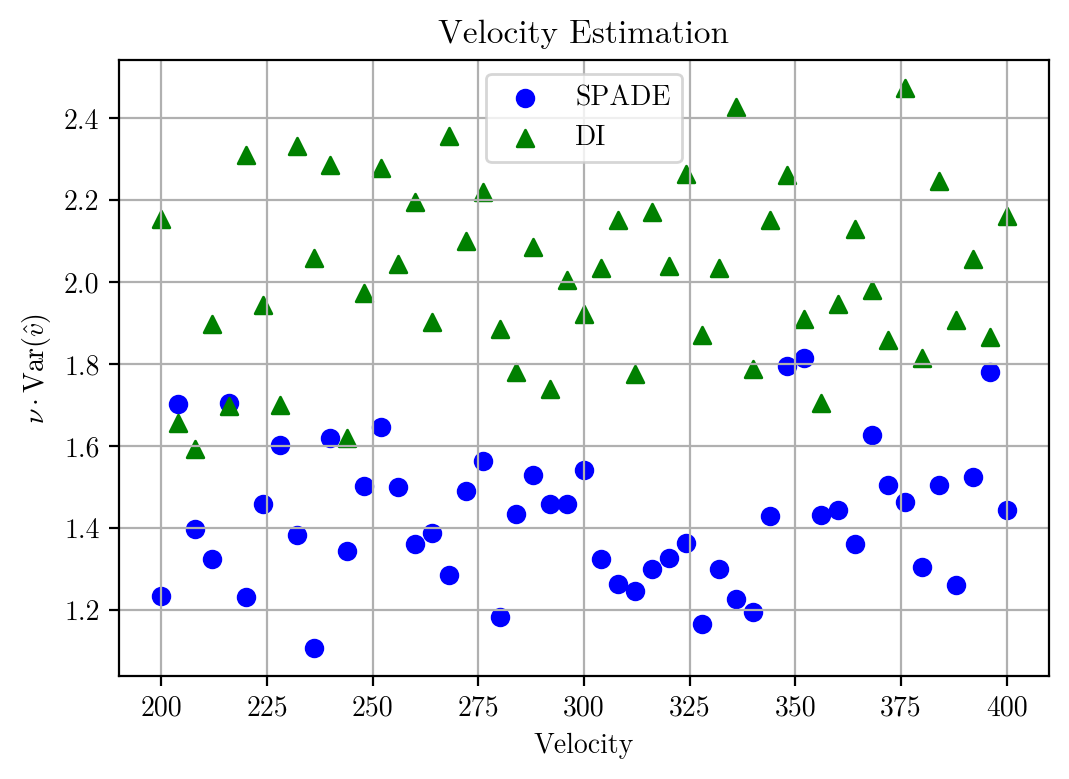

In [20]:
scatter(spadex, np.array(spadey) / crb, label='SPADE')
scatter(dix, np.array(diy) / crb, label='DI', marker='^')
plot(title='Velocity Estimation', ylabel=r'$\nu\cdot{\rm Var}(\hat v)$', xlabel='Velocity')

In [21]:
dix, diy, spadex, spadey = [], [], [], []

for f in glob('__v_est__/di*'):
    c = LoadEstimates(f)
    dix.append(c.metadata.ground_truth)
    diy.append(c.velocity_estimates.mean())


for f in glob('__v_est__/spade*'):
    c = LoadEstimates(f)
    spadex.append(c.metadata.ground_truth)
    spadey.append(c.velocity_estimates.mean())

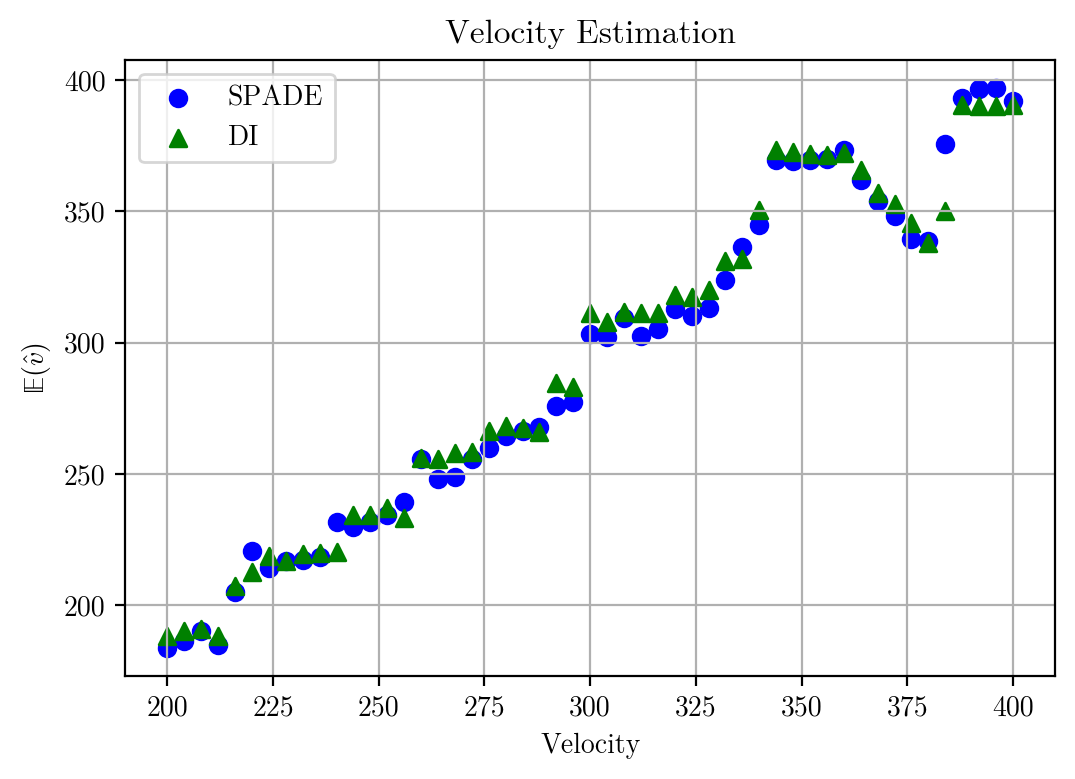

In [25]:
scatter(spadex, np.array(spadey), label='SPADE')
scatter(dix, np.array(diy), label='DI', marker='^')
plot(title='Velocity Estimation', ylabel=r'${\rm \mathbb{E}}(\hat v)$', xlabel='Velocity')